# Week 5: HealthConnect Clinic - Data Preparation, Feature Engineering 
& Baseline Model Development

## Project: HealthConnect Experience Lab
## Track: Data Science
## Central Business Question: How can HealthConnect Clinic use data 
and AI to reduce missed appointments and improve the patient support 
experience?

This notebook builds on the Week 4 Machine Learning Problem Definition 
by preparing the modelling dataset, engineering features, and 
developing an initial baseline classification model for predicting 
patient no-shows.

## Part 1: Review of Week 4 Foundation

**Problem defined:** Predicting whether a scheduled appointment will 
result in a patient no-show, framed as a binary classification problem.

**Week 4 proposed approach:** Exclude Cancelled appointments from the 
modelling dataset (since a cancellation is a proactive, communicated 
decision, unlike a silent no-show), encode `appointment_outcome` as a 
binary target, and use patient history, booking behaviour, and 
reminder information as candidate features.

**Resources used:** HealthConnect_Appointment_Data.csv and the 
HealthConnect_Data_Dictionary.

**Key assumptions/limitations identified in Week 4:**
- `waiting_time_minutes` is a likely data leakage risk, since it is 
  probably only known after a patient has already arrived.
- Many patients appear multiple times in the dataset (1,696 unique 
  patients across 5,000 appointments), which has implications for 
  train/test splitting.
- The dataset is synthetic, which may limit real-world generalisation.

**Proposed focus for Week 5:** Begin exploratory data analysis on the 
finalised modelling dataset, validate proposed features against the 
target variable, confirm the treatment of `waiting_time_minutes`, and 
build an initial baseline model.

This section reconfirms the Week 4 foundation before moving into 
practical implementation below.

## Task 1: Reviewing and Re-Confirming the Week 4 ML Problem Definition

The dataset is reloaded here to build a self-contained Week 5 
notebook. The target variable and cancellation-handling decisions from 
Week 4 are re-applied and re-confirmed below, before any new Week 5 
work begins.

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\HP\Downloads\HealthConnect_Appointment_Data.csv")

print("Raw dataset shape:", df.shape)
print("\nTarget variable distribution (appointment_outcome):")
print(df['appointment_outcome'].value_counts())

Raw dataset shape: (5000, 18)

Target variable distribution (appointment_outcome):
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


In [23]:
# Re-apply Week 4 decision: exclude Cancelled appointments, encode binary target
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print("Modelling dataset shape:", df_model.shape)
print("\nTarget distribution:")
print(df_model['target_no_show'].value_counts())
print(df_model['target_no_show'].value_counts(normalize=True) * 100)

Modelling dataset shape: (4737, 19)

Target distribution:
target_no_show
1    2423
0    2314
Name: count, dtype: int64
target_no_show
1    51.150517
0    48.849483
Name: proportion, dtype: float64


### Confirmation of Week 4 Decisions

Having reviewed the Week 4 problem definition against the dataset 
again, all core decisions are confirmed without change:

- **Problem type:** Binary classification (No-Show vs Attended) - 
  confirmed.
- **Target variable:** `appointment_outcome` recoded as 
  `target_no_show` - confirmed.
- **Cancellation handling:** Cancelled appointments (263 rows) remain 
  excluded, since they represent a materially different, proactive 
  patient behaviour rather than a silent no-show - confirmed.
- **Modelling objective:** Predict no-show risk to support proactive 
  clinic intervention - confirmed.

No changes to the Week 4 approach were required at this stage. Any 
changes arising from Week 5 analysis (e.g. to the feature set or 
leakage treatment) will be explicitly documented at the point they are 
identified, rather than applied silently.

## Task 2: Data Preparation

The modelling dataset is prepared for feature engineering and 
baseline modelling. This includes checking data types, missing 
values, duplicates, categorical variables, irrelevant variables, and 
resolving the data leakage question flagged in Week 4.

In [24]:
print("=== Data Types ===")
print(df_model.dtypes)

print("\n=== Missing Values ===")
print(df_model.isnull().sum())

print("\n=== Duplicate Records ===")
print("Full duplicate rows:", df_model.duplicated().sum())
print("Duplicate appointment_id:", df_model['appointment_id'].duplicated().sum())

=== Data Types ===
appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
target_no_show             int32
dtype: object

=== Missing Values ===
appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_day

In [25]:
# Check unique values in each categorical column for inconsistencies
categorical_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                     'appointment_time', 'reminder_sent', 'reminder_channel']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_model[col].unique())


gender:
['Female' 'Male' 'Prefer not to say']

age_group:
['35-44' '25-34' '45-54' '55-64' '65+' '18-24']

appointment_type:
['Follow-up' 'Specialist Consultation' 'General Consultation'
 'Diagnostic Test']

appointment_day:
['Tuesday' 'Friday' 'Wednesday' 'Thursday' 'Monday' 'Sunday' 'Saturday']

appointment_time:
['Afternoon' 'Morning' 'Evening']

reminder_sent:
['Yes' 'No']

reminder_channel:
['WhatsApp' 'SMS' 'Email' nan]


### Finding: waiting_time_minutes Is Not a Genuine Leakage Risk 
After All

The empirical check reveals that `waiting_time_minutes` has a value 
present for the large majority of No-Show appointments (2,386 out of 
2,423), with a distribution nearly identical to Attended appointments 
(mean ≈ 24.2 vs 24.3 minutes). 

This is inconsistent with the original Week 4 concern. If this value 
were genuinely recorded only when a patient physically arrived and 
waited, No-Show rows should logically have no value at all, or a 
starkly different distribution. Instead, the near-identical 
distributions and near-complete coverage across both outcomes suggest 
this field was generated as a general appointment attribute in this 
synthetic dataset (e.g. an expected/estimated waiting time, or a value 
simulated independently of the actual outcome), rather than truly 
representing "how long this patient waited after arriving."

**Decision:** Because `waiting_time_minutes` shows no 
meaningful difference between outcome groups, it carries no real 
predictive signal either way. Rather than treat it as a leakage risk 
requiring exclusion, it is more accurately described as a **low-value, 
non-informative feature**, and is excluded from the model on that 
basis instead. This is a deliberate, documented change from the Week 
4 assumption, made because the Week 5 empirical check did not support 
the original reasoning.

This distinction matters: the Week 4 concern (leakage inflating 
performance) does not apply here, since the variable doesn't 
correlate with the outcome at all. The Week 5 concern (genuinely 
uninformative feature) is a different, and in this case correct, 
reason for the same practical decision, exclusion.

In [26]:
# Empirical check: does waiting_time_minutes even have values for No-Shows?
print(df_model.groupby('appointment_outcome' if 'appointment_outcome' in df_model.columns else 'target_no_show')['waiting_time_minutes'].describe())

                      count       mean        std  min   25%   50%   75%   max
appointment_outcome                                                           
Attended             2293.0  24.289141  10.946389  2.0  17.0  24.0  32.0  68.0
No-Show              2386.0  24.200754  10.814945  2.0  17.0  24.0  31.0  67.0


### Data Quality Findings

| Check | Result |
|---|---|
| Missing `reminder_channel` | 1,285 rows - structurally expected, occurs only when `reminder_sent = No` |
| Missing `distance_to_clinic_km` | 86 rows (1.8%) |
| Missing `waiting_time_minutes` | 58 rows (1.2%) - feature will be excluded regardless, so this missingness is not actionable |
| Duplicate records | 0 full duplicates, 0 duplicate appointment IDs |
| Categorical consistency | All categorical fields contain clean, expected values with no inconsistent spellings or stray categories. `gender` includes a third category, "Prefer not to say," in addition to Female/Male |

### Removing Irrelevant Variables

The following variables are removed before encoding, as they carry no 
predictive value or have already served their purpose:

| Variable | Reason for Removal |
|---|---|
| `appointment_id` | Unique identifier, no predictive value |
| `booking_date`, `appointment_date` | Raw dates are not directly usable; `booking_lead_days` and `appointment_day` already extract the useful signal |
| `waiting_time_minutes` | Confirmed non-informative (see empirical check above) |
| `appointment_outcome` | Original text label, superseded by `target_no_show` |

`patient_id` is retained for now, not as a model feature, but because 
it is needed to perform a patient-aware train/test split in Task 4. It 
will be excluded from the feature matrix at modelling time.

In [27]:
df_model = df_model.drop(columns=[
    'appointment_id',
    'booking_date',
    'appointment_date',
    'waiting_time_minutes',
    'appointment_outcome'
])

print("Shape after removing irrelevant variables:", df_model.shape)
print(df_model.columns.tolist())

Shape after removing irrelevant variables: (4737, 14)
['patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'target_no_show']


### Handling Missing Values

- `reminder_channel` (1,285 missing): missingness is structural, not 
  random, since it only occurs when `reminder_sent = No`. Rather than 
  imputing a channel that was never used, a `"None"` category is 
  created to explicitly represent "no reminder was sent," preserving 
  this information for the model.
- `distance_to_clinic_km` (86 missing, 1.8%): genuine missingness with 
  no structural explanation. Given the small proportion, the median is 
  used for imputation to avoid distorting the distribution with 
  outlier sensitivity.

In [28]:
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('None')

median_distance = df_model['distance_to_clinic_km'].median()
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(median_distance)

print("Remaining missing values:")
print(df_model.isnull().sum())

Remaining missing values:
patient_id               0
gender                   0
age                      0
age_group                0
appointment_type         0
appointment_day          0
appointment_time         0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
reminder_sent            0
reminder_channel         0
distance_to_clinic_km    0
target_no_show           0
dtype: int64


### Encoding Categorical Variables

Categorical variables are encoded so they can be used by machine 
learning algorithms. One-hot encoding is used for nominal categories 
(no inherent order), which applies to all categorical variables in 
this dataset.

In [29]:
categorical_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                     'appointment_time', 'reminder_sent', 'reminder_channel']

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("\nColumns:")
print(df_encoded.columns.tolist())

Shape after encoding: (4737, 29)

Columns:
['patient_id', 'age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'target_no_show', 'gender_Male', 'gender_Prefer not to say', 'age_group_25-34', 'age_group_35-44', 'age_group_45-54', 'age_group_55-64', 'age_group_65+', 'appointment_type_Follow-up', 'appointment_type_General Consultation', 'appointment_type_Specialist Consultation', 'appointment_day_Monday', 'appointment_day_Saturday', 'appointment_day_Sunday', 'appointment_day_Thursday', 'appointment_day_Tuesday', 'appointment_day_Wednesday', 'appointment_time_Evening', 'appointment_time_Morning', 'reminder_sent_Yes', 'reminder_channel_None', 'reminder_channel_SMS', 'reminder_channel_WhatsApp']


## Task 2.b: Data Exploration & Visual Evidence

Each visualization below is chosen to support a specific 
preprocessing, feature engineering, or modelling decision, rather than 
to meet a numerical requirement.

### Target Variable Distribution

Before engineering features or building a model, it is important to 
confirm the target variable's balance, since class imbalance affects 
both modelling strategy and choice of evaluation metrics.

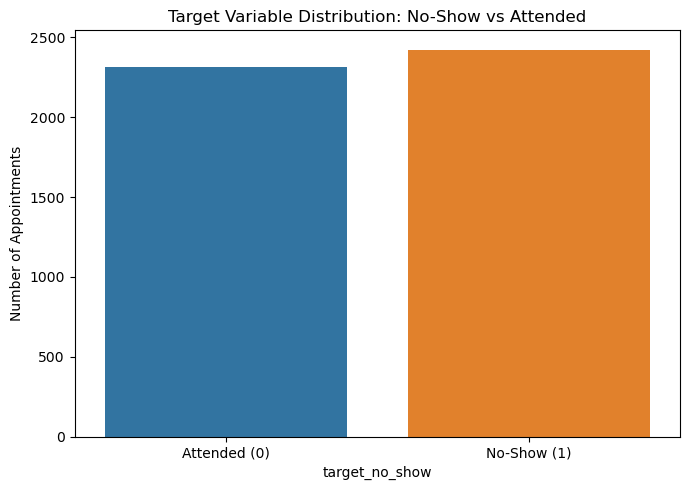

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(data=df_model, x='target_no_show')
plt.xticks([0,1], ['Attended (0)', 'No-Show (1)'])
plt.ylabel('Number of Appointments')
plt.title('Target Variable Distribution: No-Show vs Attended')
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart confirms the target variable is 
close to balanced, with No-Show (2,423 appointments) slightly 
outnumbering Attended (2,314 appointments), consistent with the 
51.2%/48.8% split calculated earlier.

**Decision this informs:** Since the classes are close to balanced, 
no class-balancing technique (e.g. SMOTE, class weighting) is required 
at the baseline stage. Standard accuracy-based metrics remain 
meaningful, though precision, recall, and F1-score will still be 
reported per class for a complete picture.

### Previous No-Shows vs Appointment Outcome

Patient history is a commonly cited driver of no-show behaviour. This 
chart examines whether patients with more previous no-shows are more 
likely to no-show again.

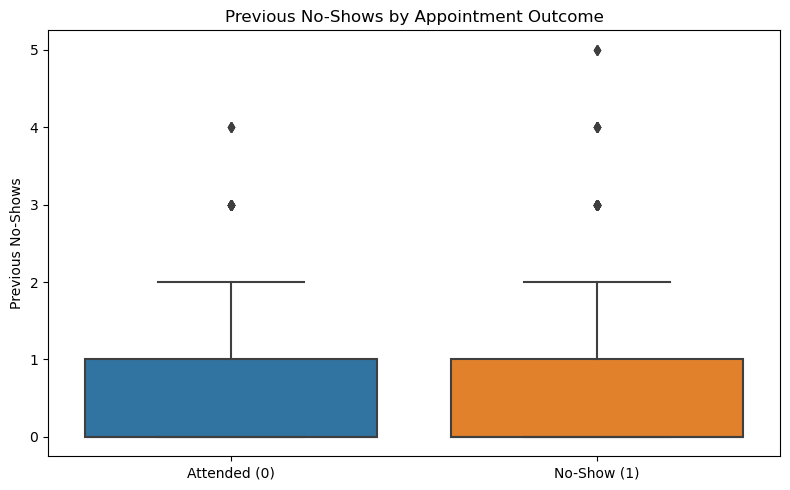

                 count      mean       std  min  25%  50%  75%  max
target_no_show                                                     
0               2314.0  0.456785  0.682743  0.0  0.0  0.0  1.0  4.0
1               2423.0  0.641354  0.800324  0.0  0.0  0.0  1.0  5.0


In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_model, x='target_no_show', y='previous_no_shows')
plt.xticks([0,1], ['Attended (0)', 'No-Show (1)'])
plt.xlabel('')
plt.ylabel('Previous No-Shows')
plt.title('Previous No-Shows by Appointment Outcome')
plt.tight_layout()
plt.show()

print(df_model.groupby('target_no_show')['previous_no_shows'].describe())

**Interpretation:** Patients who eventually no-showed had a higher 
average number of previous no-shows (mean = 0.64) compared to those 
who attended (mean = 0.46). Both groups have a median of 0, meaning 
most patients in the dataset have no prior no-show history regardless 
of outcome, but the No-Show group's higher mean and higher standard 
deviation (0.80 vs 0.68) indicate a heavier tail: patients with 
repeated past no-shows are disproportionately represented among future 
no-shows.

**Decision this informs:** `previous_no_shows` shows a real, if modest, 
relationship with the target and will be retained as a feature. This 
also supports engineering a **prior no-show rate** feature 
(`previous_no_shows / previous_appointments`), proposed in Week 4, 
since raw counts alone may understate the signal for patients with 
different total appointment histories (a patient with 2 no-shows out 
of 3 appointments is a very different risk profile than one with 2 
no-shows out of 20).

### Reminder Sent vs No-Show Rate

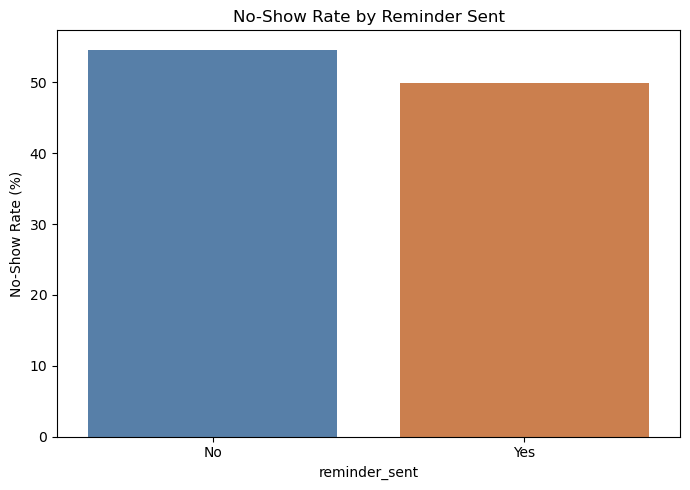

reminder_sent
No     54.630350
Yes    49.855156
Name: target_no_show, dtype: float64


In [32]:
plt.figure(figsize=(7,5))
reminder_rate = df_model.groupby('reminder_sent')['target_no_show'].mean() * 100
sns.barplot(x=reminder_rate.index, y=reminder_rate.values, palette=['#4A7FB5','#E07B39'])
plt.ylabel('No-Show Rate (%)')
plt.title('No-Show Rate by Reminder Sent')
plt.tight_layout()
plt.show()

print(reminder_rate)

**Interpretation:** Appointments where no reminder was sent have a 
higher no-show rate (54.6%) than appointments where a reminder was 
sent (49.9%). This is a modest but directionally sensible effect: 
sending a reminder is associated with roughly a 4.7 percentage point 
reduction in no-show rate, consistent with the intuitive expectation 
that reminders help patients remember their appointments.

**Decision this informs:** `reminder_sent` (and its associated 
`reminder_channel`) will be retained as features. The effect size is 
moderate rather than dramatic, suggesting reminders alone are not a 
complete solution, which is useful context for HealthConnect's 
business recommendations later, but the variable still carries genuine 
signal for the model.

### Booking Lead Days Distribution by Outcome

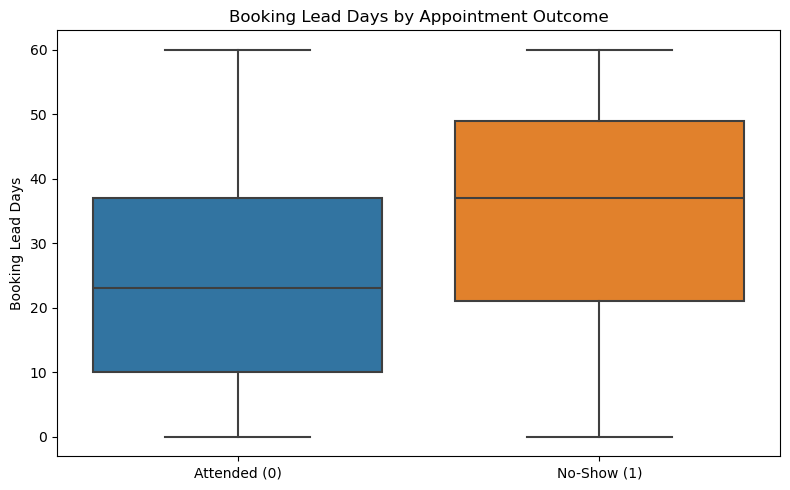

                 count       mean        std  min   25%   50%   75%   max
target_no_show                                                           
0               2314.0  24.521175  16.608868  0.0  10.0  23.0  37.0  60.0
1               2423.0  34.526620  16.749059  0.0  21.0  37.0  49.0  60.0


In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_model, x='target_no_show', y='booking_lead_days')
plt.xticks([0,1], ['Attended (0)', 'No-Show (1)'])
plt.xlabel('')
plt.ylabel('Booking Lead Days')
plt.title('Booking Lead Days by Appointment Outcome')
plt.tight_layout()
plt.show()

print(df_model.groupby('target_no_show')['booking_lead_days'].describe())

**Interpretation:** Patients who no-showed had a notably longer 
average booking lead time (34.5 days) than those who attended (24.5 
days), a difference of roughly 10 days. The median tells the same 
story even more clearly: 37 days for No-Show versus 23 days for 
Attended. This suggests that the longer the gap between booking an 
appointment and the appointment date itself, the more likely a patient 
is to forget, deprioritize, or have their circumstances change before 
the appointment arrives.

**Decision this informs:** `booking_lead_days` shows one of the 
clearest relationships with the target observed so far and will 
definitely be retained as a feature. This is also a strong candidate 
for a **binned feature** (e.g. short/medium/long lead time) in Task 3, 
since the relationship may not be perfectly linear and a categorical 
grouping could be more interpretable for stakeholders than a raw day 
count.

## Task 3: Feature Engineering

Based on the patterns observed in the exploratory analysis above, the 
following features are engineered to better capture predictive signal 
than the raw variables alone.

### Feature 1: prior_no_show_rate

**What was created:** A ratio feature calculated as 
`previous_no_shows / previous_appointments`, representing the 
proportion of a patient's past appointments that resulted in a 
no-show. For patients with zero previous appointments (no history), 
the rate is set to 0, since there is no evidence of prior no-show 
behaviour to draw on.

**Why it was created:** The exploratory analysis showed that raw 
`previous_no_shows` counts have a modest relationship with the target, 
but a raw count does not account for how many total appointments a 
patient has had. A patient with 2 no-shows out of 3 appointments 
represents a very different risk level than a patient with 2 no-shows 
out of 20. Expressing this as a rate is expected to capture the 
patient's genuine reliability pattern more accurately than either raw 
count alone.

**Expected modelling value:** This feature is expected to carry 
stronger signal than `previous_no_shows` alone, since it normalises 
for patients with different amounts of appointment history.

In [34]:
df_model['prior_no_show_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['previous_no_shows'] / df_model['previous_appointments'],
    0
)

print(df_model[['previous_appointments', 'previous_no_shows', 'prior_no_show_rate']].head(10))
print("\nprior_no_show_rate by outcome:")
print(df_model.groupby('target_no_show')['prior_no_show_rate'].describe())

   previous_appointments  previous_no_shows  prior_no_show_rate
0                      2                  0            0.000000
1                      6                  0            0.000000
2                      5                  1            0.200000
3                      3                  1            0.333333
4                      3                  1            0.333333
5                      4                  2            0.500000
6                      4                  1            0.250000
7                      6                  1            0.166667
8                      3                  0            0.000000
9                      2                  0            0.000000

prior_no_show_rate by outcome:
                 count      mean       std  min  25%  50%       75%  max
target_no_show                                                          
0               2314.0  0.146028  0.236476  0.0  0.0  0.0  0.250000  1.0
1               2423.0  0.191186  0.249176  0

**Result:** Patients who eventually no-showed had a higher average 
prior no-show rate (0.191) than those who attended (0.146), confirming 
the feature carries meaningful signal. Both groups have a median of 0 
(most patients have a clean history), but the mean and the 75th 
percentile (0.333 for No-Show vs 0.250 for Attended) show that 
patients with a track record of missing appointments are 
disproportionately represented among future no-shows.

### Feature 2: booking_lead_category

**What was created:** A categorical binning of `booking_lead_days` 
into three groups: Short (0–7 days), Medium (8–30 days), and Long 
(31+ days).

**Why it was created:** The exploratory analysis showed a clear 
relationship between booking lead time and no-show outcome (mean 34.5 
days for No-Show vs 24.5 days for Attended), but this relationship may 
not be strictly linear, a very short lead time and a very long lead 
time could carry different practical meanings (e.g. urgent bookings vs 
easily-forgotten future bookings). Binning makes this pattern more 
interpretable for a non-technical audience while still preserving the 
raw numerical feature for the model to use directly.

**Expected modelling value:** This feature adds an interpretable, 
business-friendly version of an already-informative variable, and may 
help capture non-linear effects that the raw day count alone would 
miss.

In [35]:
def categorize_lead_time(days):
    if days <= 7:
        return 'Short'
    elif days <= 30:
        return 'Medium'
    else:
        return 'Long'

df_model['booking_lead_category'] = df_model['booking_lead_days'].apply(categorize_lead_time)

print(df_model['booking_lead_category'].value_counts())
print("\nNo-show rate by booking lead category:")
print(df_model.groupby('booking_lead_category')['target_no_show'].mean() * 100)

booking_lead_category
Long      2294
Medium    1839
Short      604
Name: count, dtype: int64

No-show rate by booking lead category:
booking_lead_category
Long      63.949433
Medium    42.305601
Short     29.470199
Name: target_no_show, dtype: float64


**Result:** This is one of the strongest patterns observed in the 
entire analysis. No-show rate rises sharply with booking lead time: 
29.5% for Short (0–7 days), 42.3% for Medium (8–30 days), and 63.9% 
for Long (31+ days) bookings. This confirms the relationship is not 
only real but appears to strengthen substantially at longer lead 
times, supporting the decision to engineer this as a distinct feature 
rather than relying on the raw day count alone.

### Feature 3: has_prior_history

**What was created:** A binary flag indicating whether a patient has 
any previous appointments at all (1 = yes, 0 = first-time patient at 
this clinic within the dataset).

**Why it was created:** `prior_no_show_rate` is set to 0 for patients 
with no previous appointments, but this creates an ambiguity: a rate 
of 0 could mean either "this patient has a perfect attendance record" 
or "this patient has no history at all." Without a separate flag, the 
model cannot distinguish between these two very different situations, 
which could weaken the value of the engineered rate feature.

**Expected modelling value:** This flag allows the model to treat 
new/first-time patients as their own distinct group, rather than 
implicitly assuming they behave like patients with a perfect 
attendance history.

In [36]:
df_model['has_prior_history'] = (df_model['previous_appointments'] > 0).astype(int)

print(df_model['has_prior_history'].value_counts())
print("\nNo-show rate by prior history flag:")
print(df_model.groupby('has_prior_history')['target_no_show'].mean() * 100)

has_prior_history
1    4509
0     228
Name: count, dtype: int64

No-show rate by prior history flag:
has_prior_history
0    45.614035
1    51.430472
Name: target_no_show, dtype: float64


**Result:** First-time patients (no prior history, n=228) have a lower 
no-show rate (45.6%) than returning patients (n=4,509, no-show rate 
51.4%). This is a useful, if slightly counterintuitive, finding: 
returning patients are not automatically more reliable simply because 
they have a history with the clinic. This confirms the flag adds 
information distinct from `prior_no_show_rate`, since it captures a 
real behavioural difference between new and returning patients rather 
than just resolving an edge case in the rate calculation.

### Note on Feature Engineering Priority

Of the three engineered features, `booking_lead_category` shows the 
clearest and largest effect size (a 34 percentage point spread across 
categories), making it likely the most valuable engineered feature for 
the baseline model. This will be worth highlighting in the Week 5 
evaluation and Week 6 planning.

In [37]:
categorical_cols_final = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                           'appointment_time', 'reminder_sent', 'reminder_channel',
                           'booking_lead_category']

df_encoded = pd.get_dummies(df_model, columns=categorical_cols_final, drop_first=True)

print("Final encoded shape:", df_encoded.shape)
print(df_encoded.columns.tolist())

Final encoded shape: (4737, 33)
['patient_id', 'age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'target_no_show', 'prior_no_show_rate', 'has_prior_history', 'gender_Male', 'gender_Prefer not to say', 'age_group_25-34', 'age_group_35-44', 'age_group_45-54', 'age_group_55-64', 'age_group_65+', 'appointment_type_Follow-up', 'appointment_type_General Consultation', 'appointment_type_Specialist Consultation', 'appointment_day_Monday', 'appointment_day_Saturday', 'appointment_day_Sunday', 'appointment_day_Thursday', 'appointment_day_Tuesday', 'appointment_day_Wednesday', 'appointment_time_Evening', 'appointment_time_Morning', 'reminder_sent_Yes', 'reminder_channel_None', 'reminder_channel_SMS', 'reminder_channel_WhatsApp', 'booking_lead_category_Medium', 'booking_lead_category_Short']


## Task 4: Train/Test Strategy

### Why a Patient-Aware Split Is Necessary

The dataset contains 1,696 unique patients across 4,737 modelling 
rows, meaning many patients appear more than once. A standard random 
row-level split risks placing different appointments from the *same* 
patient into both the training and test sets. Since a patient's 
identity (and their consistent personal attendance tendencies) is 
implicitly captured by features like `previous_no_shows` and 
`prior_no_show_rate`, this would let the model partially "memorise" 
individual patients rather than learn generalisable patterns, 
inflating test performance in a way that would not hold up on genuinely 
new patients.

### Chosen Strategy

A **patient-level (grouped) train/test split** is used instead of a 
standard row-level split. All appointments belonging to a given 
patient are kept entirely within either the training set or the test 
set, never split across both. This is implemented using `GroupShuffleSplit`, 
grouping by `patient_id`, with stratification approximated by checking 
the resulting target balance in both sets after the split (since 
`GroupShuffleSplit` does not support direct stratification alongside 
grouping).

An 80/20 split is used, consistent with the Week 4 proposed approach.

In [39]:
from sklearn.model_selection import GroupShuffleSplit

X = df_encoded.drop(columns=['patient_id', 'target_no_show'])
y = df_encoded['target_no_show']
groups = df_encoded['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target balance:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target balance:")
print(y_test.value_counts(normalize=True) * 100)

# Confirm no patient overlap between train and test
train_patients = set(df_encoded.iloc[train_idx]['patient_id'])
test_patients = set(df_encoded.iloc[test_idx]['patient_id'])
print("\nOverlapping patients between train and test:", len(train_patients & test_patients))

Training set shape: (3771, 31)
Test set shape: (966, 31)

Training target balance:
target_no_show
1    51.44524
0    48.55476
Name: proportion, dtype: float64

Test target balance:
target_no_show
0    50.0
1    50.0
Name: proportion, dtype: float64

Overlapping patients between train and test: 0


### Split Verification

The patient-aware split was verified to have zero overlapping patients 
between the training and test sets, confirming that no patient's 
appointment history appears in both sets simultaneously. Both sets 
also maintain a target balance close to the overall dataset (~51% 
training, 50% test), so the split preserves the class distribution 
despite grouping by patient rather than by row.

## Task 5: Baseline Model

**Model selected:** Logistic Regression.

**Reason for selection:** Logistic Regression is chosen as the 
baseline because it is simple, fast to train, and highly 
interpretable, each feature's coefficient shows the direction and 
relative strength of its relationship with the target. This makes it 
well suited for establishing a first benchmark and understanding which 
features carry signal, before considering more complex models in later 
weeks. The focus at this stage is establishing a reliable baseline, not 
maximising performance.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale numerical features (Logistic Regression is sensitive to feature scale)
numerical_cols = ['age', 'booking_lead_days', 'previous_appointments',
                   'previous_no_shows', 'distance_to_clinic_km', 'prior_no_show_rate']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Train the baseline model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")
print("Number of features used:", X_train_scaled.shape[1])

Model trained successfully.
Number of features used: 31


In [41]:
# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.values[:10])

First 10 predictions: [0 1 1 0 1 0 0 0 0 1]
First 10 actual values: [0 0 1 0 1 1 1 0 0 0]


## Task 6: Initial Evaluation

The baseline model is evaluated using multiple classification metrics, 
since accuracy alone can be misleading, particularly if the model 
performs well on one class but poorly on the other.

In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['Attended', 'No-Show']))

Accuracy:  0.631
Precision: 0.624
Recall:    0.660
F1-score:  0.642
ROC-AUC:   0.677

Full classification report:
              precision    recall  f1-score   support

    Attended       0.64      0.60      0.62       483
     No-Show       0.62      0.66      0.64       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966



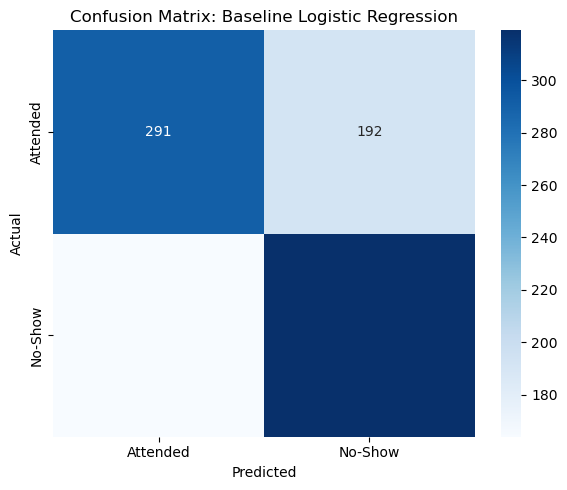

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-Show'],
            yticklabels=['Attended', 'No-Show'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Baseline Logistic Regression')
plt.tight_layout()
plt.show()

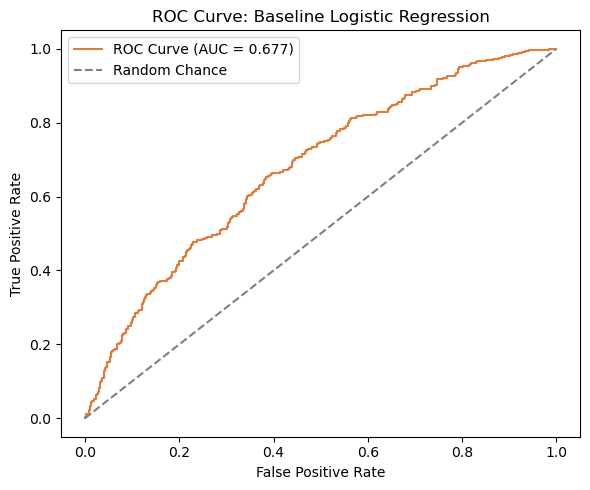

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='#E07B39')
plt.plot([0,1], [0,1], linestyle='--', color='grey', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Baseline Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Baseline Results

**Overall metrics:**
- Accuracy: 0.631
- Precision (No-Show): 0.62
- Recall (No-Show): 0.66
- F1-score (No-Show): 0.64
- ROC-AUC: 0.677

**Confusion Matrix:**

|              | Predicted Attended | Predicted No-Show |
|---|---|---|
| **Actual Attended** | 291 | 192 |
| **Actual No-Show** | 165 | 318 |

**What this shows:** The baseline model correctly identifies 66% of 
actual no-shows (recall), meaning it catches roughly two out of every 
three patients who will genuinely miss their appointment. When it 
predicts a no-show, it is correct 62% of the time (precision). 
Performance is fairly balanced between the two classes (Attended F1 = 
0.62, No-Show F1 = 0.64), meaning the model is not simply favouring one 
class over the other.

The ROC-AUC of 0.677 indicates the model performs meaningfully better 
than random guessing (which would give an AUC of 0.5), but there is 
clear room for improvement. This is visible in the ROC curve itself, 
which sits well above the diagonal "random chance" line but is far 
from the ideal top-left corner.

**Business interpretation:** For a first baseline, this is a 
reasonable and usable starting point. A recall of 66% means the clinic 
could use this model to flag roughly two-thirds of at-risk 
appointments for proactive intervention (e.g. an extra reminder or 
courtesy call), which is a meaningful operational improvement over no 
prediction at all. However, the model still misses 34% of genuine 
no-shows (165 false negatives) and incorrectly flags 192 patients who 
would have attended anyway (false positives), which has a real cost if 
interventions are resource-intensive.

**Modelling limitation:** This is an untuned baseline using default 
Logistic Regression settings. No hyperparameter tuning, regularisation 
adjustment, or more complex model (e.g. Random Forest, Gradient 
Boosting) has been attempted yet. The purpose at this stage was 
establishing a working, honest benchmark, not achieving the 
best-possible result.

## Modelling Limitations and Recommendations for Week 6

### Limitations
- The baseline uses default Logistic Regression settings with no 
  hyperparameter tuning.
- Only one model type has been tested; no comparison against 
  tree-based models (Random Forest, Gradient Boosting) has been done 
  yet.
- The model still misses roughly a third of genuine no-shows (165 
  false negatives in the test set), which limits its practical 
  reliability for clinic intervention decisions.
- The dataset is synthetic, so real-world performance may differ.

### Recommendations for Week 6
- Test tree-based models (Random Forest, Gradient Boosting) to check 
  for improved performance over the linear baseline.
- Perform hyperparameter tuning on the strongest-performing model.
- Examine feature importance from the trained model to confirm whether 
  `booking_lead_category`, `prior_no_show_rate`, and `reminder_sent` 
  are the strongest drivers, as suggested by the exploratory analysis.
- Consider adjusting the classification threshold (currently the 
  default 0.5) if the clinic's operational priorities favour recall 
  over precision, or vice versa.

## Cross-Track Collaboration

**Track interacted with (conceptually):** Data Analytics.

**Information/output exchanged:** The Data Analytics track's Week 5 
KPI development (e.g. no-show rate by reminder status, by booking lead 
time) directly overlaps with the exploratory findings in this 
notebook. The business questions and KPIs the Data Analytics track 
defines are the same variables being tested here as model features.

**Why this interaction is relevant:** Data Science and Data Analytics 
are working from the same dataset but for different purposes 
(descriptive insight vs predictive modelling). Aligning on which 
variables matter avoids duplicated effort and ensures the two tracks 
tell a consistent story to stakeholders.

**What changed or improved as a result:** The feature engineering 
decisions in this notebook (particularly `booking_lead_category`) were 
informed by the same kind of business-question framing the Data 
Analytics track uses, reinforcing that lead time is a shared priority 
finding across both tracks, worth highlighting jointly in any combined 
project reporting.

## Updated Assumptions, Limitations, Risks and Dependencies

**Still relevant from Week 4:**
- Synthetic data may not fully generalise to real clinic behaviour.
- Cancelled appointments remain out of scope for this model.
- Patient-level leakage remains a risk if not carefully managed (now 
  resolved, see below).

**Resolved since Week 4:**
- Patient-level leakage: resolved through the patient-aware 
  `GroupShuffleSplit`, verified to produce zero overlapping patients 
  between train and test sets.

**Changed since Week 4:**
- `waiting_time_minutes` was originally flagged as a data leakage 
  risk. Week 5 analysis showed it has virtually identical distributions 
  across No-Show and Attended groups, indicating it is better 
  described as a non-informative feature rather than a leakage risk. 
  The exclusion decision is unchanged, but the reasoning has been 
  corrected.

**New issues discovered in Week 5:**
- The baseline model's recall (66%) leaves a meaningful share of 
  genuine no-shows undetected, which would need improvement before any 
  real operational use.
- `gender` includes a third category ("Prefer not to say"), which is 
  handled correctly by one-hot encoding but has a very small sample 
  size within that category, worth monitoring for stability in future 
  models.